In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report





In [4]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Gender için Label Encoding
label_encoder = LabelEncoder()
df["Gender"] = label_encoder.fit_transform(df["Gender"])

# Geography için One-Hot Encoding
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [7]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10000, 11)
y shape: (10000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [11]:
y_pred = nb_model.predict(X_test)


In [12]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[1526,   81],
       [ 252,  141]])

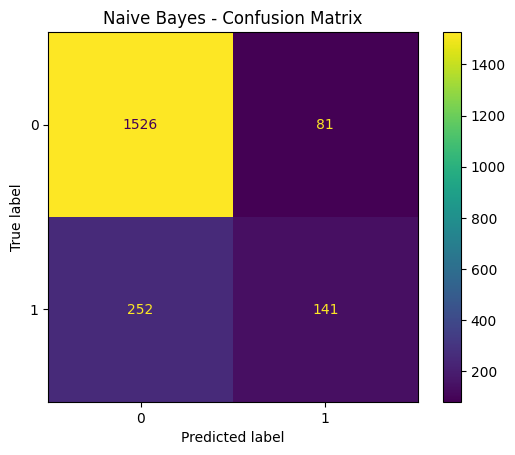

In [36]:
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_nb.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


Accuracy : 0.8335
Precision: 0.6351
Recall   : 0.3588
F1-Score : 0.4585


In [14]:
from sklearn.tree import DecisionTreeClassifier


In [15]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
y_pred_dt = dt_model.predict(X_test)


In [17]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_dt


array([[1559,   48],
       [ 237,  156]])

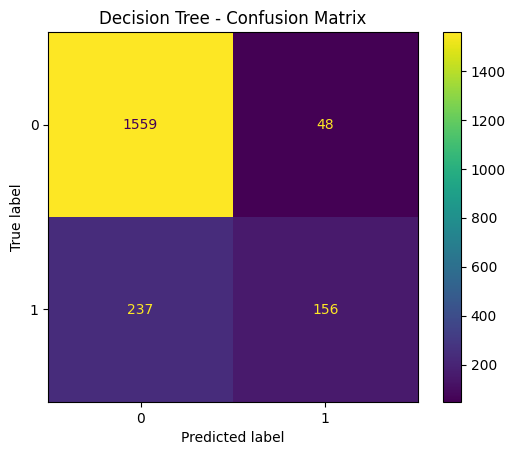

In [37]:
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()


In [18]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")


Accuracy : 0.8575
Precision: 0.7647
Recall   : 0.3969
F1-Score : 0.5226


In [19]:
from sklearn.neighbors import KNeighborsClassifier


In [20]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="minkowski",
    p=2  # Euclidean distance
)

knn_model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred_knn = knn_model.predict(X_test)


In [22]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_knn


array([[1514,   93],
       [ 247,  146]])

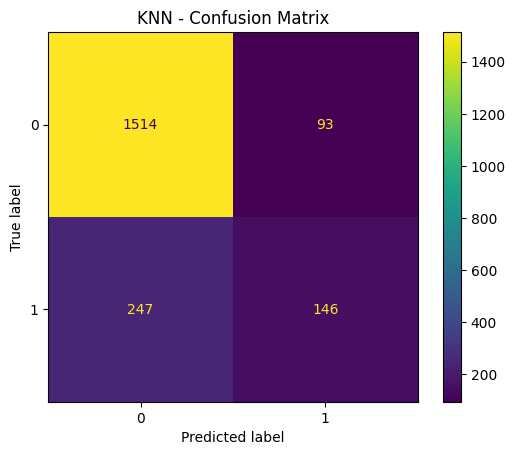

In [38]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title("KNN - Confusion Matrix")
plt.show()


In [23]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1-Score : {f1_knn:.4f}")


Accuracy : 0.8300
Precision: 0.6109
Recall   : 0.3715
F1-Score : 0.4620


In [24]:
from sklearn.svm import SVC


In [25]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
y_pred_svm = svm_model.predict(X_test)


In [27]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm


array([[1562,   45],
       [ 243,  150]])

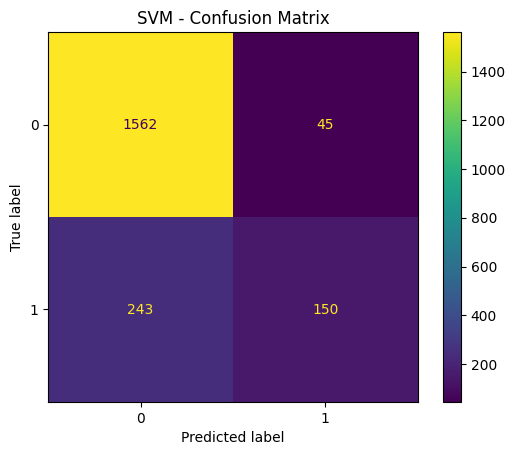

In [39]:
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot()
plt.title("SVM - Confusion Matrix")
plt.show()


In [28]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")


Accuracy : 0.8560
Precision: 0.7692
Recall   : 0.3817
F1-Score : 0.5102


In [30]:
from sklearn.neural_network import MLPClassifier


In [31]:
ann_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

ann_model.fit(X_train, y_train)


,hidden_layer_sizes,"(16, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [32]:
y_pred_ann = ann_model.predict(X_test)


In [33]:
cm_ann = confusion_matrix(y_test, y_pred_ann)
cm_ann


array([[1532,   75],
       [ 200,  193]])

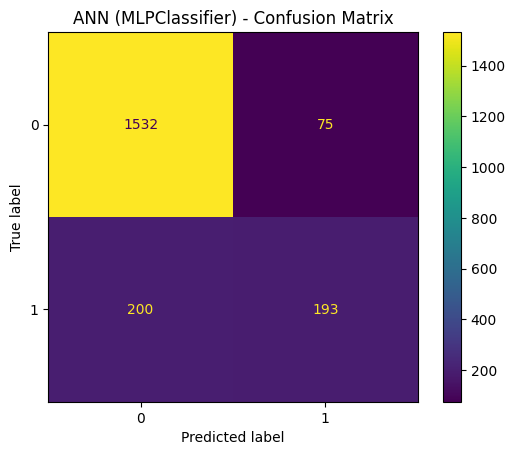

In [40]:
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann)
disp_ann.plot()
plt.title("ANN (MLPClassifier) - Confusion Matrix")
plt.show()


In [34]:
accuracy_ann = accuracy_score(y_test, y_pred_ann)
precision_ann = precision_score(y_test, y_pred_ann)
recall_ann = recall_score(y_test, y_pred_ann)
f1_ann = f1_score(y_test, y_pred_ann)

print(f"Accuracy : {accuracy_ann:.4f}")
print(f"Precision: {precision_ann:.4f}")
print(f"Recall   : {recall_ann:.4f}")
print(f"F1-Score : {f1_ann:.4f}")


Accuracy : 0.8625
Precision: 0.7201
Recall   : 0.4911
F1-Score : 0.5840


In [41]:
from sklearn.linear_model import LinearRegression


In [42]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred_lr_prob = lr_model.predict(X_test)

# İlk birkaç tahmini görelim
y_pred_lr_prob[:5]


array([0.26600737, 0.09381542, 0.32510027, 0.43306721, 0.05067363])

In [44]:
# 0.5 eşik değeri kullanarak sınıflandırma
y_pred_lr = (y_pred_lr_prob >= 0.5).astype(int)


In [45]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr


array([[1574,   33],
       [ 341,   52]])

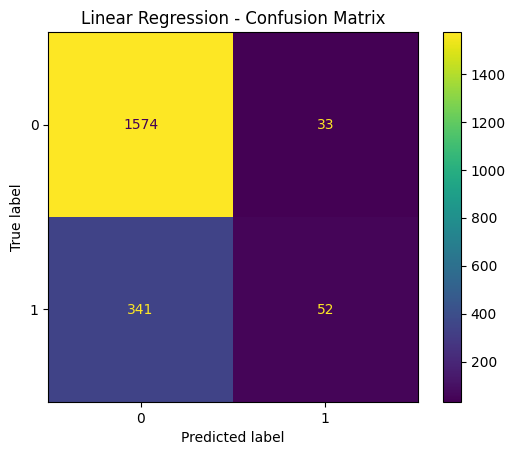

In [47]:
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title("Linear Regression - Confusion Matrix")
plt.show()


In [46]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")


Accuracy : 0.8130
Precision: 0.6118
Recall   : 0.1323
F1-Score : 0.2176


In [48]:
ysa_model = MLPClassifier(
    hidden_layer_sizes=(32, 16, 8),
    activation='relu',
    solver='adam',
    max_iter=700,
    random_state=42
)

ysa_model.fit(X_train, y_train)


,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,700
,shuffle,True
,random_state,42


In [49]:
y_pred_ysa = ysa_model.predict(X_test)


In [50]:
cm_ysa = confusion_matrix(y_test, y_pred_ysa)
cm_ysa


array([[1505,  102],
       [ 195,  198]])

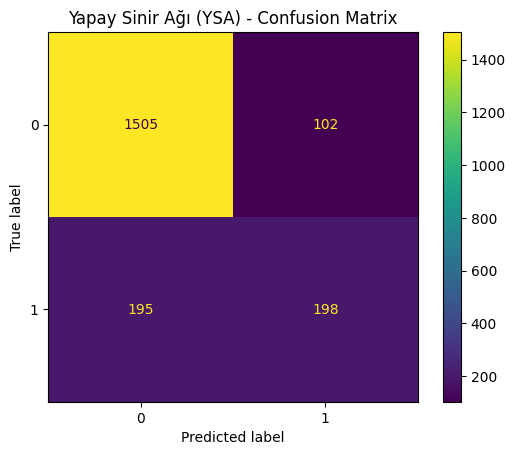

In [51]:
disp_ysa = ConfusionMatrixDisplay(confusion_matrix=cm_ysa)
disp_ysa.plot()
plt.title("Yapay Sinir Ağı (YSA) - Confusion Matrix")
plt.show()


In [52]:
accuracy_ysa = accuracy_score(y_test, y_pred_ysa)
precision_ysa = precision_score(y_test, y_pred_ysa)
recall_ysa = recall_score(y_test, y_pred_ysa)
f1_ysa = f1_score(y_test, y_pred_ysa)

print(f"Accuracy : {accuracy_ysa:.4f}")
print(f"Precision: {precision_ysa:.4f}")
print(f"Recall   : {recall_ysa:.4f}")
print(f"F1-Score : {f1_ysa:.4f}")


Accuracy : 0.8515
Precision: 0.6600
Recall   : 0.5038
F1-Score : 0.5714


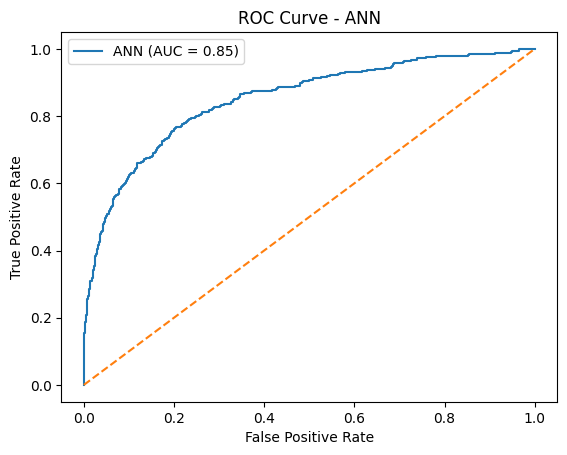

In [53]:
from sklearn.metrics import roc_curve, auc

y_prob_ann = ann_model.predict_proba(X_test)[:, 1]

fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)
roc_auc_ann = auc(fpr_ann, tpr_ann)

plt.figure()
plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC = {roc_auc_ann:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN")
plt.legend()
plt.show()


In [58]:
pipeline_ann = Pipeline([
    ('scaler', StandardScaler()),
    ('ann', MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_ann,
    X,
    y,
    cv=skf,
    scoring='f1'
)

print("F1 CV Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

F1 CV Scores: [0.56145675 0.56379822 0.59562044 0.61471861 0.56756757]
Mean F1: 0.580632318496499
